# Figure 6E: GSEA

Run cells from top to bottom. Paths and thread counts are centralized in `config/`; embedded plots are retained as visual references from the source analysis.


In [ ]:
# Centralized paths and scheduler-aware thread limits.
repo_root <- if (file.exists("config/paths.R")) "." else if (file.exists("../config/paths.R")) ".." else stop("Run Jupyter from the repository root or notebooks/ directory.")
source(file.path(repo_root, "config", "paths.R"))


Warning message:
“replacing previous import ‘AnnotationDbi::select’ by ‘dplyr::select’ when loading ‘GseaVis’”
Warning message:
“replacing previous import ‘purrr::exec’ by ‘yulab.utils::exec’ when loading ‘GseaVis’”


目标细胞亚群: 4 CD115+ CDP 
完整输出目录已自动设置为: /data3/Group8/gonglihao/20250604p38-afterYZ/passway-gene/4CD115CDP 

细胞亚群提取完成。细胞数: 1523 
JoinLayers 运行成功。
正在进行差异基因分析 (KO vs WT)...
差异基因分析完成。

--- 开始 GSEA 分析与可视化 ---
已创建排序基因列表，包含 1696 个基因。
正在为小鼠 (Mus musculus) 合并 KEGG, Hallmark, GO:BP 基因集...
基因集合并完成，共包含 7892 个通路。
正在运行 GSEA (这将需要一些时间)...


Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“For some of the pathways the P-values were likely overestimated. For such pathways log2err is set to NA.”
Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“For some pathways, in reality P-values are less than 1e-10. You can set the `eps` argument to zero for better estimation.”


GSEA 运行完成，耗时: 11.8 秒。
GSEA 分析完成，正在使用 gseaNb 可视化指定通路...
将为以下找到的通路绘制 GSEA 图:
[1] "GOBP_DNA_REPLICATION"                                                 
[2] "GOBP_IMMUNE_RESPONSE"                                                 
[3] "GOBP_RESPONSE_TO_CYTOKINE"                                            
[4] "GOBP_TRANSMEMBRANE_RECEPTOR_PROTEIN_TYROSINE_KINASE_SIGNALING_PATHWAY"
✅ 使用 gseaNb 绘制的 GSEA 图已成功保存至: /data3/Group8/gonglihao/20250604p38-afterYZ/passway-gene/4CD115CDP/4CD115CDP_GSEA_SelectedPathways.pdf 

--- 所有分析流程已完成 ---


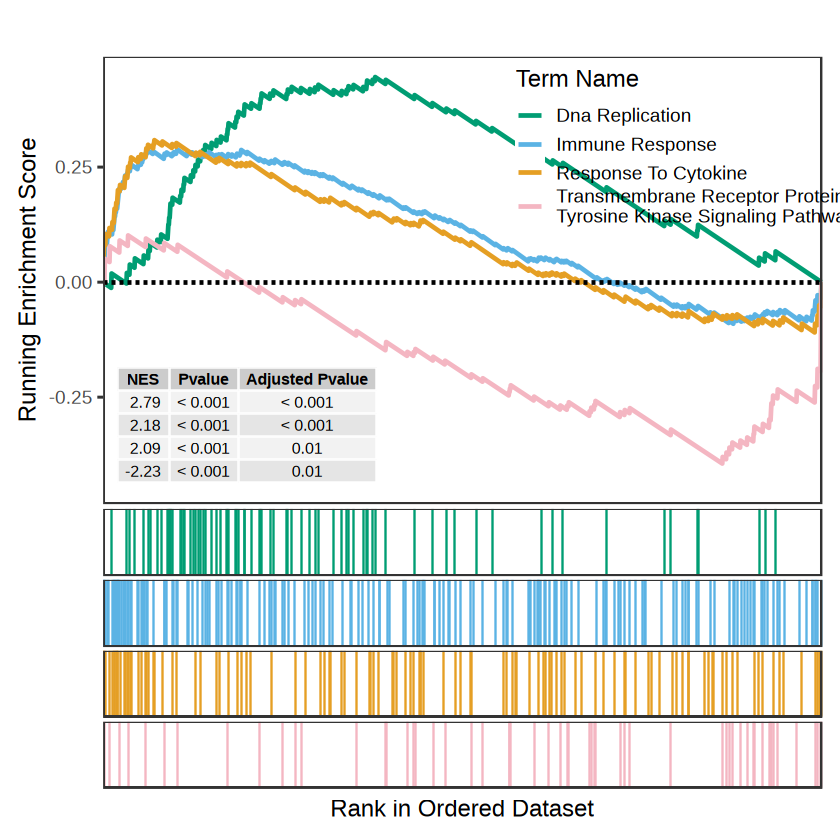

In [1]:
suppressPackageStartupMessages({
    library(dplyr)
    library(Seurat)
    library(clusterProfiler)
    library(org.Mm.eg.db)         # 小鼠物种注释包
    library(msigdbr)              # MSigDB 基因集
    library(ggplot2)              # 绘图
    library(tibble)               # 用于 rownames_to_column
    library(GseaVis)              # GSEA 可视化
    library(tidyverse)            # 包含 dplyr, tibble 等
})


# --- 2. 设置路径和核心参数 ---
#----------------------------------------------------
# !! 您只需要修改下面这 3 行 !!
base_output_dir <- legacy_path("20250611-p38-draw/pathway") # 基础输出目录
seu_path        <- legacy_path("20250604p38-afterYZ/anno.rds")     # Seurat对象路径
target_celltype <- "4 CD115+ CDP"                                              # 核心参数：目标细胞亚群

# --- 自动准备 ---
# 从细胞类型名称创建一个对文件名安全的字符串 (移除空格、斜杠、加号)
filename_safe_celltype <- gsub("[ /+]+", "", target_celltype)

# 自动构建完整的输出目录
output_dir <- file.path(base_output_dir, filename_safe_celltype)
dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)

cat("目标细胞亚群:", target_celltype, "\n")
cat("完整输出目录已自动设置为:", output_dir, "\n\n")

# 读取 Seurat 对象
seu <- readRDS(seu_path)

# 提取目标细胞亚群
PDC <- subset(seu, subset = celltype %in% target_celltype)
PDC$celltype <- droplevels(PDC$celltype)
cat("细胞亚群提取完成。细胞数:", ncol(PDC), "\n")

# 设置分组信息
Idents(PDC) <- "orig.ident"

# 运行 JoinLayers
tryCatch({
  if (length(Assays(PDC)) > 0) {
     DefaultAssay(PDC) <- Assays(PDC)[1]
     PDC <- JoinLayers(PDC)
     cat("JoinLayers 运行成功。\n")
  } else { warning("未找到任何 Assay，跳过 JoinLayers。") }
}, error = function(e) { cat("运行 JoinLayers 时出错:", conditionMessage(e), "\n") })


# --- 3. 差异基因表达分析 (为 GSEA 做准备) ---
#----------------------------------------------------
cat("正在进行差异基因分析 (KO vs WT)...\n")
deg_result <- FindMarkers(
  object = PDC, ident.1 = "KO", ident.2 = "WT", min.pct = 0.25,
  logfc.threshold = 0.25, test.use = "wilcox", assay = DefaultAssay(PDC), verbose = FALSE
)

# 添加基因名列，为后续操作做准备
deg_result <- deg_result %>%
  rownames_to_column(var = "gene")

cat("差异基因分析完成。\n\n")


# --- 4. GSEA (基因集富集分析) 与 可视化 ---
#----------------------------------------------------
cat("--- 开始 GSEA 分析与可视化 ---\n")

# (1) 准备 GSEA 需要的排序基因列表 (衔接 DEG 结果)
# 使用 deg_result 和 avg_log2FC 列
gene_list_ranked <- deg_result %>%
  dplyr::select(gene, avg_log2FC) %>%
  filter(!is.na(avg_log2FC) & is.finite(avg_log2FC)) %>%
  group_by(gene) %>%
  # 如果有重复基因，选择 logFC 绝对值最大的那个
  slice_max(abs(avg_log2FC), n=1, with_ties=FALSE) %>%
  ungroup() %>%
  deframe() %>%
  sort(decreasing = TRUE)

if(length(gene_list_ranked) == 0) { stop("错误: 无法创建有效的排序基因列表。") }
cat("已创建排序基因列表，包含", length(gene_list_ranked), "个基因。\n")


# (2) 准备 GSEA 需要的基因集 (合并 Hallmark, KEGG, GO:BP)
# **注意：物种已从 "Homo sapiens" 修改为 "Mus musculus" 以匹配您的数据**
cat("正在为小鼠 (Mus musculus) 合并 KEGG, Hallmark, GO:BP 基因集...\n")
gene_set_categories <- list(
  KEGG = list(category = "C2", subcategory = "CP:KEGG"),
  Hallmark = list(category = "H"),
  GO_BP = list(category = "C5", subcategory = "GO:BP")
)
combined_term2gene <- NULL
for (cat_name in names(gene_set_categories)) {
  params <- gene_set_categories[[cat_name]]
  current_sets <- tryCatch({
    msigdbr(species = "Mus musculus", category = params$category, subcategory = params$subcategory) %>%
      dplyr::select(gs_name, gene_symbol)
  }, error = function(e) {NULL})
  if (!is.null(current_sets)) {
    combined_term2gene <- bind_rows(combined_term2gene, current_sets)
  } else { warning(paste("未能获取", cat_name, "基因集。")) }
}
if (is.null(combined_term2gene)) { stop("错误: 未能获取任何基因集用于合并 TERM2GENE。") }
combined_term2gene <- combined_term2gene %>% distinct()
cat("基因集合并完成，共包含", length(unique(combined_term2gene$gs_name)), "个通路。\n")


# (3) 运行统一的 GSEA 分析
cat("正在运行 GSEA (这将需要一些时间)...\n")
start_time_gsea <- Sys.time()
gsea_combined_results <- tryCatch({
    GSEA(geneList = gene_list_ranked,
         TERM2GENE = combined_term2gene,
         minGSSize = 15,    # 最小基因集大小
         maxGSSize = 500,   # 最大基因集大小
         pvalueCutoff = 1.0,  # 先不过滤，获取所有结果
         pAdjustMethod = "BH",
         verbose = FALSE)
}, error = function(e) { cat("错误: GSEA 运行失败:", conditionMessage(e), "\n"); NULL })
end_time_gsea <- Sys.time()
time_taken_gsea <- difftime(end_time_gsea, start_time_gsea, units = "secs")
cat(paste("GSEA 运行完成，耗时:", round(as.numeric(time_taken_gsea), 1), "秒。\n"))

# (4) 使用 GseaVis::gseaNb 可视化指定的四个通路
if (is.null(gsea_combined_results) || !inherits(gsea_combined_results, "gseaResult") || nrow(gsea_combined_results@result) == 0) {
    cat("GSEA 未生成有效结果，无法进行可视化。\n")
} else {
    cat("GSEA 分析完成，正在使用 gseaNb 可视化指定通路...\n")

    # 指定您想绘制的通路 ID
    target_pathway_ids_for_plot <- c(
        'GOBP_DNA_REPLICATION',
        'GOBP_IMMUNE_RESPONSE',
        'GOBP_RESPONSE_TO_CYTOKINE',
        'GOBP_TRANSMEMBRANE_RECEPTOR_PROTEIN_TYROSINE_KINASE_SIGNALING_PATHWAY'
    )

    all_ids_in_result <- gsea_combined_results@result$ID
    found_ids <- intersect(target_pathway_ids_for_plot, all_ids_in_result)
    missing_ids <- setdiff(target_pathway_ids_for_plot, found_ids)

    if (length(missing_ids) > 0) {
        warning(paste("警告: 以下通路 ID 未在 GSEA 结果中找到:", paste(missing_ids, collapse=", ")))
    }
    if (length(found_ids) == 0) {
        stop("错误: 所有指定绘图的通路 ID 均未在 GSEA 结果中找到。")
    }

    cat("将为以下找到的通路绘制 GSEA 图:\n")
    print(found_ids)

    # 设置颜色
    num_colors_needed <- length(found_ids)
    user_colors <- c("#009D73", "#5BB3E4", "#E59F24", "#F4B6C2")
    curve_colors <- rep(user_colors, length.out = num_colors_needed)

    gsea_plot_object <- NULL
    tryCatch({
      gsea_plot_object <- gseaNb(
          object = gsea_combined_results,
          geneSetID = found_ids,
          subPlot = 2,
          addPval = TRUE,
          pvalX = 0.02, pvalY = -0.05,
          rmHt = TRUE,
          termWidth = 35, # 稍微加宽以容纳长名称
          base_size = 14,
          legend.position = c(0.8, 0.8),
          curveCol = curve_colors
      )

      # 在交互式环境中（如 RStudio）直接打印以预览
      if (!is.null(gsea_plot_object)) {
          print(gsea_plot_object)
      }

    }, error = function(e) {
      cat("错误: 在生成 gseaNb 图形时发生错误:", conditionMessage(e), "\n")
      gsea_plot_object <- NULL
    })

    # 将生成的图形保存为 PDF 文件
    if (!is.null(gsea_plot_object)) {
        # 使用动态文件名保存
        output_pdf_path <- file.path(output_dir, paste0(filename_safe_celltype, "_GSEA_SelectedPathways.pdf"))
        tryCatch({
          ggsave(filename = output_pdf_path, plot = gsea_plot_object,
                 width = 7.5, height = 6.5, device = "pdf")
          cat("✅ 使用 gseaNb 绘制的 GSEA 图已成功保存至:", output_pdf_path, "\n")
        }, error = function(e) {
            cat("错误: 保存 PDF 文件失败:", conditionMessage(e), "\n")
        })
    } else {
        cat("由于未能成功生成绘图对象，跳过 PDF 保存步骤。\n")
    }
}

cat("\n--- 所有分析流程已完成 ---\n")